# 05 · ML task T2: JD scanner (model zoo, validation, product demo)
**Team DSA · NEXUS DELTA · Build for Bharat 2.0 Round 2**  
Run top-to-bottom (Colab: Runtime → Run all). Notebooks 01→06 share files in `out/`.

In [1]:
import os, json, re, warnings, time
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
SEED = 42
np.random.seed(SEED)
# ---- Colab: upload the 4 organiser files to /content (left sidebar) or mount Drive and change DATA_DIR ----
DATA_DIR = "."
os.makedirs("figs", exist_ok=True); os.makedirs("out", exist_ok=True)
RES = "out/results.json"
def save_res(key, val):
    r = json.load(open(RES)) if os.path.exists(RES) else {}
    r[key] = val
    json.dump(r, open(RES, "w"), indent=1, default=float)
plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 9, "axes.titlesize": 10, "axes.titleweight": "bold"})
C = {"navy": "#12355b", "teal": "#1b998b", "amber": "#e09f3e", "red": "#c8553d", "grey": "#8d99ae"}

## 1. Task T2 — “JD scanner”: estimate a posting’s salary-band distribution
Target: 6 ordered bands. Population: wide DS&A postings. Validation: **GroupKFold by normalised designation** so near-identical titles never straddle train/test.

In [2]:
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, cohen_kappa_score, mean_absolute_error, confusion_matrix
a = pd.read_csv("out/analytics_clean.csv"); df = a[a.is_ds_w].reset_index(drop=True)
df["text"] = (df.job_desig.fillna("") + " " + df.key_skills.fillna("")).str.lower()
df["grp"] = df.job_desig.str.lower().str.replace(r"[^a-z ]", " ", regex=True).str.split().str.join(" ")
y = df.salary_ord.values; G = df.grp.astype("category").cat.codes.values
FL = [f"{k}_w" for k in ["big_data","maths_stats","coding","ai_ml","viz","mis"]]
NUM = ["exp_min","exp_max","exp_span"]; CAT = ["seniority","loc_tier","role_family"]; META = ["jobtype_missing","trunc_skills","desc_missing"]
print(f"n={len(df)}, groups={len(set(G))}, band distribution:", np.bincount(y)/len(y))
def prep(num, cat, flags, text=False):
    t = [("num", StandardScaler(), num)] if num else []
    if cat: t.append(("cat", OneHotEncoder(handle_unknown="ignore"), cat))
    if flags: t.append(("flag", "passthrough", flags))
    if text: t.append(("tfidf", TfidfVectorizer(max_features=3000, ngram_range=(1,2), sublinear_tf=True, min_df=3), "text"))
    return ColumnTransformer(t)
LR = lambda C=1.0: LogisticRegression(C=C, max_iter=600)
MODELS = {
 "B0 majority":                 Pipeline([("p", prep([], [], ["exp_min"])), ("m", DummyClassifier(strategy="prior"))]),
 "B1 experience-only LR":       Pipeline([("p", prep(["exp_min","exp_max"], [], [])), ("m", LR())]),
 "M0 structured LR (no flags)": Pipeline([("p", prep(NUM, CAT, META)), ("m", LR())]),
 "M1 structured LR (+flags)":   Pipeline([("p", prep(NUM, CAT, FL+META)), ("m", LR())]),
 "M2 TF-IDF + structured LR":   Pipeline([("p", prep(NUM, CAT, FL+META, text=True)), ("m", LR(0.5))]),
 "M3 random forest":            Pipeline([("p", prep(NUM, CAT, FL+META)), ("m", RandomForestClassifier(300, min_samples_leaf=3, n_jobs=-1, random_state=SEED))]),
 "M4 hist-gradient boosting":   Pipeline([("p", prep(NUM, CAT, FL+META)), ("m", HistGradientBoostingClassifier(max_iter=250, learning_rate=0.06, max_depth=5, random_state=SEED))]),
}
def evaluate(model, y_=y, G_=G, ret_proba=False):
    P = np.zeros((len(y_), 6))
    for tr, te in GroupKFold(5).split(df, y_, G_):
        m = __import__("sklearn").base.clone(model).fit(df.iloc[tr], y_[tr]); pr = m.predict_proba(df.iloc[te])
        P[np.ix_(te, m.classes_)] = pr
    pred = P.argmax(1)
    r = dict(acc=accuracy_score(y_, pred), qwk=cohen_kappa_score(y_, pred, weights="quadratic"), within1=float((abs(pred-y_)<=1).mean()), mae=mean_absolute_error(y_, pred))
    return (r, P) if ret_proba else r
t0 = time.time(); res, probs = {}, {}
for n, m in MODELS.items(): res[n], probs[n] = evaluate(m, ret_proba=True); print(f"{n:30s}", {k: round(v,3) for k, v in res[n].items()}, f"[{time.time()-t0:.0f}s]")
save_res("t2_models", res)

n=10338, groups=6741, band distribution: [0.15612304 0.14025924 0.20139292 0.2387309  0.198491   0.0650029 ]
B0 majority                    {'acc': 0.239, 'qwk': 0.0, 'within1': 0.639, 'mae': 1.279} [0s]


B1 experience-only LR          {'acc': 0.383, 'qwk': 0.655, 'within1': 0.811, 'mae': 0.854} [1s]


M0 structured LR (no flags)    {'acc': 0.414, 'qwk': 0.677, 'within1': 0.82, 'mae': 0.823} [5s]


M1 structured LR (+flags)      {'acc': 0.423, 'qwk': 0.688, 'within1': 0.826, 'mae': 0.806} [10s]


M2 TF-IDF + structured LR      {'acc': 0.444, 'qwk': 0.719, 'within1': 0.851, 'mae': 0.749} [21s]


M3 random forest               {'acc': 0.419, 'qwk': 0.672, 'within1': 0.815, 'mae': 0.829} [27s]


M4 hist-gradient boosting      {'acc': 0.42, 'qwk': 0.672, 'within1': 0.815, 'mae': 0.829} [40s]


## 2. Validation: do capability flags add signal? permutation test, confusion matrix, probability calibration

QWK gain from capability flags (M1-M0): 0.011  95% CI [0.006, 0.016]


permutation QWK null: mean=-0.000, max=0.008  vs observed 0.688
                 conf    hit
(0.22, 0.35]    0.313  0.323
(0.35, 0.401]   0.376  0.378
(0.401, 0.453]  0.427  0.408
(0.453, 0.537]  0.490  0.454
(0.537, 0.985]  0.685  0.657
best by QWK: M2 TF-IDF + structured LR


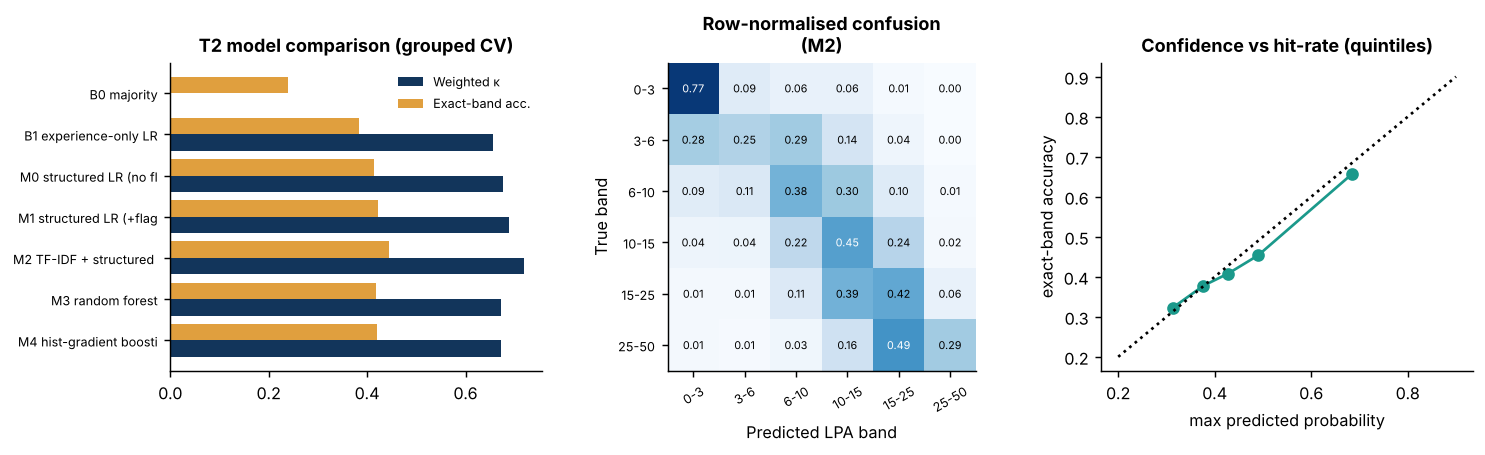

In [3]:
# (a) paired bootstrap on out-of-fold predictions: M1 (+flags) vs M0 (no flags) -- QWK difference
rng = np.random.default_rng(SEED); p1, p0 = probs["M1 structured LR (+flags)"].argmax(1), probs["M0 structured LR (no flags)"].argmax(1); d = []
for _ in range(1000):
    i = rng.integers(0, len(y), len(y)); d.append(cohen_kappa_score(y[i], p1[i], weights="quadratic") - cohen_kappa_score(y[i], p0[i], weights="quadratic"))
print(f"QWK gain from capability flags (M1-M0): {np.mean(d):.3f}  95% CI [{np.percentile(d,2.5):.3f}, {np.percentile(d,97.5):.3f}]")
# (b) permutation test on M1: 40 label shuffles (group-preserving CV)
null = []
for i in range(40):
    ys = np.random.default_rng(500+i).permutation(y); null.append(evaluate(MODELS["M1 structured LR (+flags)"], y_=ys)["qwk"])
print(f"permutation QWK null: mean={np.mean(null):.3f}, max={np.max(null):.3f}  vs observed {res['M1 structured LR (+flags)']['qwk']:.3f}")
# (c) confidence discipline: does max-probability track accuracy?
Pm = probs["M2 TF-IDF + structured LR"]; conf = Pm.max(1); hit = (Pm.argmax(1) == y)
bins = pd.qcut(conf, 5, duplicates="drop"); cal = pd.DataFrame({"conf": conf, "hit": hit}).groupby(bins).mean()
print(cal.round(3).to_string())
best = max(res, key=lambda k: res[k]["qwk"]); print("best by QWK:", best)
save_res("t2_validation", dict(qwk_gain=float(np.mean(d)), qwk_gain_lo=float(np.percentile(d,2.5)), qwk_gain_hi=float(np.percentile(d,97.5)),
         null_mean=float(np.mean(null)), null_max=float(np.max(null)), best=best, n=len(df), groups=int(len(set(G))), cal_conf=cal.conf.tolist(), cal_acc=cal.hit.tolist()))
BANDS = ["0-3","3-6","6-10","10-15","15-25","25-50"]
fig, ax = plt.subplots(1, 3, figsize=(11.5, 3.5))
names = list(res); qw = [res[n]["qwk"] for n in names]; ac = [res[n]["acc"] for n in names]
yy = np.arange(len(names)); ax[0].barh(yy+0.2, qw, 0.4, color=C["navy"], label="Weighted κ"); ax[0].barh(yy-0.2, ac, 0.4, color=C["amber"], label="Exact-band acc.")
ax[0].set_yticks(yy); ax[0].set_yticklabels([n.split(" ",1)[0]+" "+n.split(" ",1)[1][:20] for n in names], fontsize=7); ax[0].invert_yaxis(); ax[0].legend(frameon=False, fontsize=7); ax[0].set_title("T2 model comparison (grouped CV)")
cm = confusion_matrix(y, probs[best].argmax(1), normalize="true"); im = ax[1].imshow(cm, cmap="Blues", vmin=0, vmax=0.8)
ax[1].set_xticks(range(6)); ax[1].set_xticklabels(BANDS, fontsize=7, rotation=30); ax[1].set_yticks(range(6)); ax[1].set_yticklabels(BANDS, fontsize=7)
for i in range(6):
    for j in range(6): ax[1].text(j, i, f"{cm[i,j]:.2f}", ha="center", va="center", fontsize=6, color="white" if cm[i,j]>0.45 else "black")
ax[1].set_title(f"Row-normalised confusion\n({best.split(' ',1)[0]})"); ax[1].set_xlabel("Predicted LPA band"); ax[1].set_ylabel("True band")
ax[2].plot(cal.conf, cal.hit, "o-", color=C["teal"]); ax[2].plot([0.2,0.9],[0.2,0.9], ":", color="k"); ax[2].set_title("Confidence vs hit-rate (quintiles)"); ax[2].set_xlabel("max predicted probability"); ax[2].set_ylabel("exact-band accuracy")
plt.tight_layout(); plt.savefig("figs/fig05_t2_scanner.png", bbox_inches="tight"); plt.show()

## 3. The scanner as a product: paste a JD → capability tags + salary-band probability distribution

In [4]:
import re
TXN = json.load(open("out/taxonomy.json")); TAX = TXN["TAX"]
final = MODELS["M2 TF-IDF + structured LR"].fit(df, y)
import joblib; joblib.dump(final, "out/jd_scanner_m2.joblib")   # consumed by the demo app
def scan(designation, skills, description="", exp_min=3, exp_max=6, loc_tier="Tier1", seniority="mid", role_family="DA_BI"):
    t = (designation + " " + skills + " " + description).lower()
    row = dict(job_desig=designation, text=(designation+" "+skills).lower(), exp_min=exp_min, exp_max=exp_max, exp_span=exp_max-exp_min,
               seniority=seniority, loc_tier=loc_tier, role_family=role_family, jobtype_missing=1, trunc_skills=0, desc_missing=int(description==""))
    tags = {k: int(bool(re.search(p, t))) for k, p in TAX.items()}
    for k, v in tags.items(): row[f"{k}_w"] = v
    pr = final.predict_proba(pd.DataFrame([row]))[0]
    return {k for k, v in tags.items() if v}, pr
demos = [("Senior Data Scientist", "python, machine learning, tensorflow, nlp, sql", 6, 10, "senior", "DS_ML"),
         ("MIS Executive", "excel, mis reporting, vba, reports", 1, 3, "mid", "DA_BI"),
         ("Data Visualisation Analyst", "tableau, power bi, dashboards, sql", 3, 6, "mid", "DA_BI")]
demo_out = []
for d_, s_, lo, hi, sen, rf in demos:
    tags, pr = scan(d_, s_, exp_min=lo, exp_max=hi, seniority=sen, role_family=rf)
    print(f"{d_:28s} tags={sorted(tags)}  P(band)=" + " ".join(f"{b}:{p:.2f}" for b, p in zip(BANDS, pr)))
    demo_out.append(dict(title=d_, tags=sorted(tags), probs=pr.tolist()))
save_res("t2_demo", demo_out)

Senior Data Scientist        tags=['ai_ml', 'coding']  P(band)=0-3:0.00 3-6:0.04 6-10:0.16 10-15:0.47 15-25:0.25 25-50:0.07
MIS Executive                tags=['mis']  P(band)=0-3:0.88 3-6:0.09 6-10:0.02 10-15:0.01 15-25:0.00 25-50:0.00
Data Visualisation Analyst   tags=['coding', 'viz']  P(band)=0-3:0.09 3-6:0.22 6-10:0.44 10-15:0.20 15-25:0.05 25-50:0.00
